In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

2025-04-22 13:46:03.305489: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.85. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana1/snert/max/data/amigo_files/"
    data_path = "/media/morgana1/snert/max/data/JWST/"
    uncal_path = "/media/morgana1/snert/max/data/JWST/"
else:
    cache = "/Volumes/morgana1/snert/max/data/amigo_files/"
    data_path = "/Users/mcha5804/JWST/"
    uncal_path = "/Users/mcha5804/JWST/"

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    "F430M",
    "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

In [ ]:
def get_rgb(
    TARGPROP,
    PATT_NUM=1,
    NUMDTHPT=1,
):
    files = sorted(
        file_fn(data_path + "AB-DOR/calslope/"),
        key=lambda hdu: hdu[0].header.get("EXPMID", float("inf")),
    )

    channels = {}
    for file in files:
        if (
            file[0].header["PATT_NUM"] != PATT_NUM
            or file[0].header["NUMDTHPT"] != NUMDTHPT
        ):
            continue
        if file[0].header["TARGPROP"] == TARGPROP:
            for filt in FILTERS:
                if file[0].header["FILTER"] == filt:
                    channels[filt] = file

    return channels


def normalise_rgb(rgb_dict, p=1.0):

    r = np.array(rgb_dict["F480M"]["SLOPE"].data[0])
    g = np.array(rgb_dict["F430M"]["SLOPE"].data[0])
    b = np.array(rgb_dict["F380M"]["SLOPE"].data[0])

    r_badpix = np.array(rgb_dict["F480M"]["BADPIX"].data)
    g_badpix = np.array(rgb_dict["F430M"]["BADPIX"].data)
    b_badpix = np.array(rgb_dict["F380M"]["BADPIX"].data)

    badpix = r_badpix | g_badpix | b_badpix

    r_max = np.nanmax(r)
    g_max = np.nanmax(g)
    b_max = np.nanmax(b)
    maxx = np.nanmax(np.array([r_max, g_max, b_max]))

    r = np.clip(np.where(badpix, 0.0, r), 0.0) / maxx
    g = np.clip(np.where(badpix, 0.0, g), 0.0) / maxx
    b = np.clip(np.where(badpix, 0.0, b), 0.0) / maxx

    return np.stack([r**p, g**p, b**p], axis=-1)  # Shape: (H, W, 3)

# Loading in data

## AB-DOR

In [40]:
files = file_fn(
    data_path + "AB-DOR/calslope/",
    filters=FILTERS,
)

for file in files:
    print(file[0].header["PATT_NUM"], file[0].header["NUMDTHPT"])

25 25
1 1
4 5
6 25
5 5
13 25
2 25
1 5
17 25
1 1
16 25
14 25
3 25
1 25
4 5
9 25
1 1
8 25
4 25
1 1
11 25
1 1
1 1
15 25
19 25
12 25
3 5
7 25
1 1
1 1
22 25
2 5
3 5
18 25
2 5
1 2
1 1
10 25
1 1
5 25
23 25
1 1
1 2
1 1
1 1
1 1
1 1
5 5
24 25
1 1
21 25
1 1
20 25
1 1
1 5
1 2
1 1
1 1


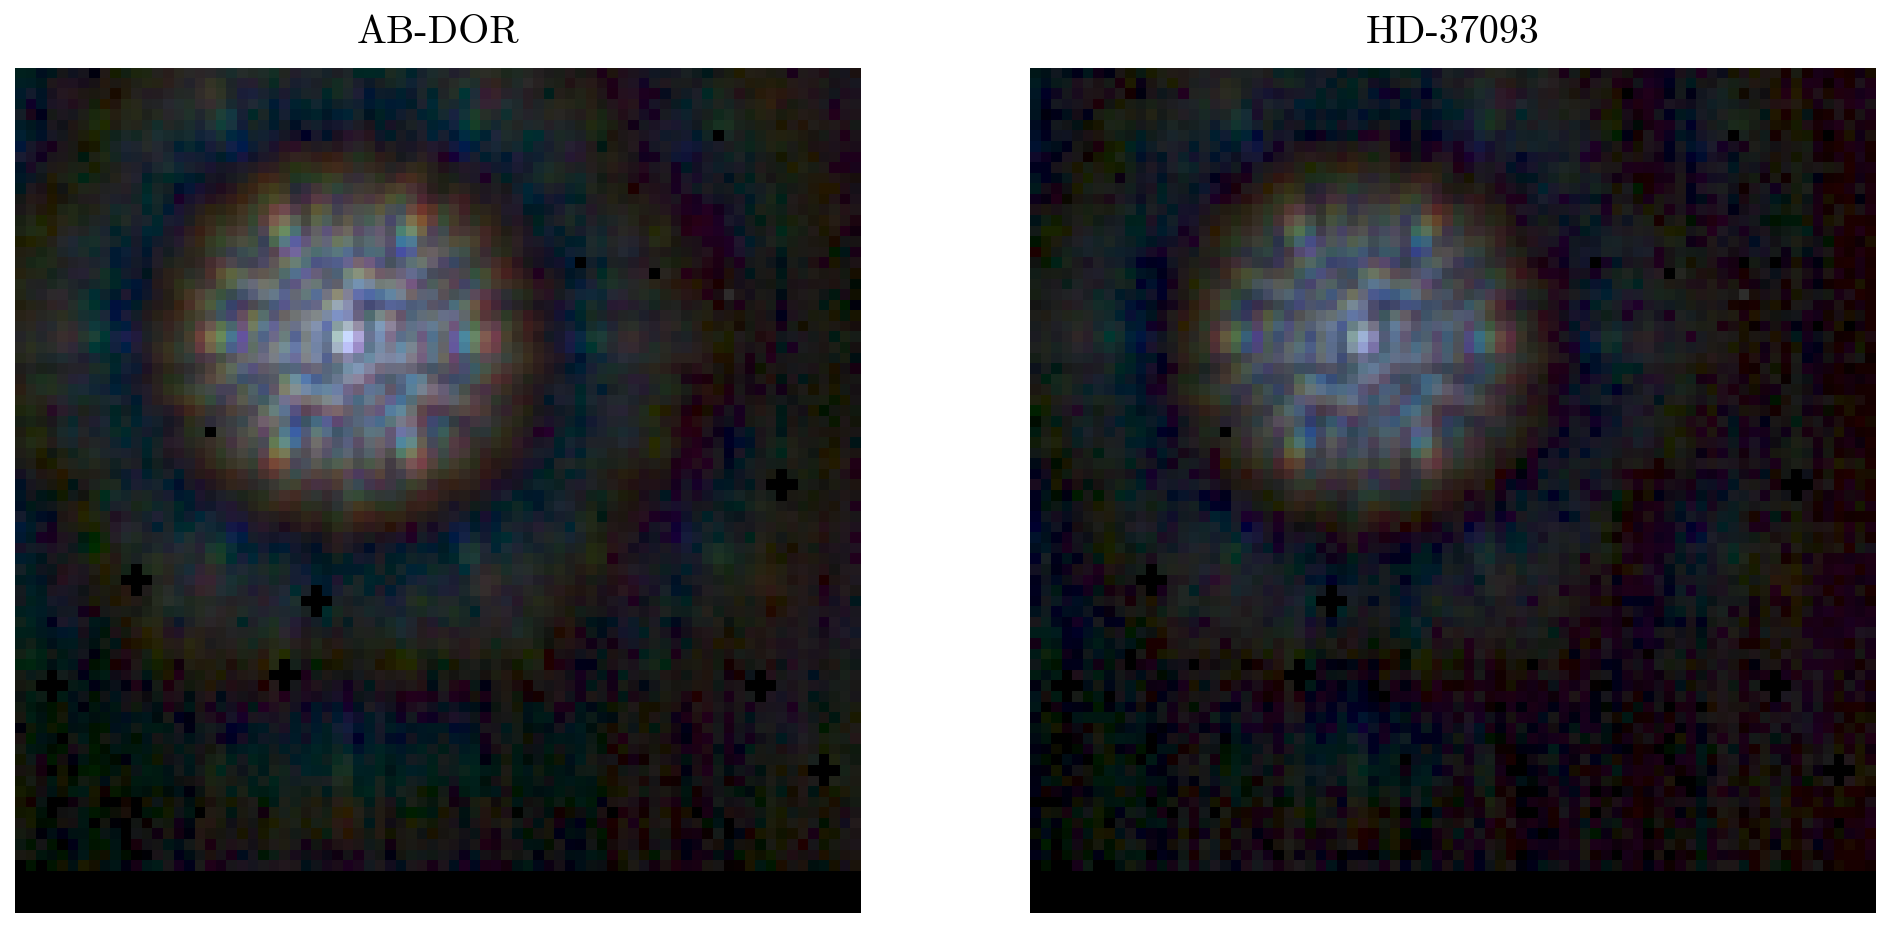

In [45]:
abdor, abdorcal = get_rgb("AB-DOR", "HD-37093")

# for filt, ch in abdor.items():
#     # print(ch[0].header)


abdor_rgb = normalise_rgb(abdor, p=0.3)
abdorcal_rgb = normalise_rgb(abdorcal, p=0.3)


fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

ax[0].imshow(abdor_rgb, origin="lower")
ax[0].set(title="AB-DOR")
ax[0].axis("off")

ax[1].imshow(abdorcal_rgb, origin="lower")
ax[1].set(title="HD-37093")
ax[1].axis("off")

plt.show()

In [31]:
ch[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE    = '2023-06-26T18:16:39.185' / UTC date file created                     
ORIGIN  = 'STSCI   '           / Organization responsible for creating file     
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw01093013001_03104_00001_0001_nis_calslope.fits' / Name of the file 
SDP_VER = '2023_1a '           / Data processing software version number        
PRD_VER = 'PRDOPSSOC-061'      / S&OC PRD version number used in data processing
OSS_VER = '008.004.007.000'    / Observatory Scheduling Software (OSS) version n
DATAMODL= 'Level1bModel'    

In [ ]:
badpix = cal_fits[0].badpix

r = fits_filt["F480M"][0]
g = fits_filt["F430M"][0]
b = fits_filt["F380M"][0]

r_max = np.nanmax(r)
g_max = np.nanmax(g)
b_max = np.nanmax(b)
maxx = np.nanmax(np.array([r_max, g_max, b_max]))

r = np.clip(np.where(badpix, 0.0, r), 0.0) / maxx
g = np.clip(np.where(badpix, 0.0, g), 0.0) / maxx
b = np.clip(np.where(badpix, 0.0, b), 0.0) / maxx

p = 0.5
r = r**p
g = g**p
b = b**p

img = np.stack([r, g, b], axis=-1)  # Shape: (H, W, 3)

plt.imshow(
    img, norm=mpl.colors.PowerNorm(2.0), origin="lower", interpolation="spline16"
)
plt.axis("off")
plt.show()

In [ ]:
cal_files["F430M"][0].header["TARGPROP"]

'HD-37093'

In [ ]:
file[-5].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                   80                                                  
NAXIS2  =                   80                                                  
NAXIS3  =                    9                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
EXTNAME = 'SLOPE   '                                                            

In [ ]:
badpix = cal_fits[0].badpix

r = fits_filt["F480M"][0]
g = fits_filt["F430M"][0]
b = fits_filt["F380M"][0]

r_max = np.nanmax(r)
g_max = np.nanmax(g)
b_max = np.nanmax(b)
maxx = np.nanmax(np.array([r_max, g_max, b_max]))

r = np.clip(np.where(badpix, 0.0, r), 0.0) / maxx
g = np.clip(np.where(badpix, 0.0, g), 0.0) / maxx
b = np.clip(np.where(badpix, 0.0, b), 0.0) / maxx

p = 0.5
r = r**p
g = g**p
b = b**p

img = np.stack([r, g, b], axis=-1)  # Shape: (H, W, 3)

plt.imshow(
    img, norm=mpl.colors.PowerNorm(2.0), origin="lower", interpolation="spline16"
)
plt.axis("off")
plt.show()

In [ ]:
sci["BADPIX"]

In [ ]:
for hdu in sci:
    hd

{'_header_str': None, '_file': <astropy.io.fits.file._File <_io.BufferedReader name='/media/morgana1/snert/max/data/JWST/AB-DOR/calslope/jw01093012001_03102_00001_0001_nis_calslope.fits'>>, '_buffer': None, '_header_offset': 0, '_data_offset': 20160, '_data_size': 0, '_data_replaced': False, '_data_needs_rescale': False, '_new': False, '_output_checksum': False, '_checksum': None, '_checksum_valid': None, '_datasum': None, '_datasum_valid': None, '_do_not_scale_image_data': False, '_uint': True, '_scale_back': None, '_bzero': 0, '_bscale': 1, '_axes': [], '_bitpix': 8, '_gcount': 1, '_pcount': 0, '_blank': None, '_orig_bitpix': 8, '_orig_blank': None, '_orig_bzero': 0, '_orig_bscale': 1, '_modified': False, '_header': SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    

TypeError: 'PrimaryHDU' object is not subscriptable

In [ ]:
import jax.random as jr
from amigo.rnn_models import PixelNonLinearity, ConvRNN, RNNRamp

ramp_model = ConvRNN(key=jr.key(0), use_bias=False, bias_value=1e-3)
ramp_model = RNNRamp(ramp_model, gain_model=PixelNonLinearity())

In [ ]:
source_size = 112
# level = 5
# # shearlets, shearletSystem = dorito.build_model.shearlet_prior(source_size, nScales=2)
# wavelets = dorito.wavelets.Wavelets(
#     np.ones((source_size, source_size)), level=level, wavelet="db2"
# )

model, params, cal_fits, sci_fits = dorito.build_model.build_resolved_model(
    # model, params, cal_exposures, sci_exposures = dorito.build_model.build_resolved_model(
    cal_files,
    # [],
    # sci_files[3:4],
    # cal_files,
    sci_files,
    # [],
    state=state,
    modeller=dorito.models.ResolvedAmigoModel,
    ramp_model=ramp_model,
    extra_priors={
        # "approx": np.log10(wavelets.approx),
        # "details": wavelets.values,
        "log_distribution": np.log10(
            np.ones((source_size, source_size)) / source_size**2
        ),
        "spectral_coeffs": np.array([1.0, 0.0]),
    },
    sci_fit=dorito.model_fits.DynamicResolvedFit,
    # sci_fit=dorito.model_fits.ResolvedFit,
    Teff_cache=teff_cache,
    separate_fits=True,
)
fits = [*cal_fits, *sci_fits]

# # init state
# init_state = np.load(init_state_cache + "F430M.npy", allow_pickle=True)[()]
# for p in [
#     "positions",
#     "fluxes",
#     "aberrations",
#     # "log_distribution",
# ]:
#     for key in init_state[p].keys():
#         params[p][key] = init_state[p][key]

#     # params[p] = init_state[p]
# model = model.set("params", params)

model = model.set("FF", np.load(os.path.join(model_cache, "FF.npy")))
model = model.set(
    "non_linearity", np.load(os.path.join(model_cache, "non_linearities.npy"))
)

In [ ]:
fits_filt = {
    "F480M": [f.slopes[-1] for f in fits if f.filter == "F480M" and f.dither == "1"],
    "F430M": [f.slopes[-1] for f in fits if f.filter == "F430M" and f.dither == "1"],
    "F380M": [f.slopes[-1] for f in fits if f.filter == "F380M" and f.dither == "1"],
}

In [ ]:
fits_filt

{'F480M': [Array([[ 2.25439453,  1.12597656, -1.06137824, ...,  3.30407071,
           1.11445582,  0.78926283],
         [-0.6696226 ,  1.34501004,  0.4717311 , ...,  1.3377279 ,
          -1.08677042,  1.80497468],
         [ 1.62242544,  3.01028538,  0.69599313, ...,  0.77123427,
           0.92819625, -3.05062699],
         ...,
         [ 1.6647135 ,  0.72207034, -1.35677087, ...,  3.951823  ,
           4.01559544, -1.64278924],
         [ 0.30506727,  1.12448299,  2.02729225, ...,  3.20000935,
           1.96922743, -0.77321696],
         [ 1.28850818, -1.62185335, -1.73979807, ...,  1.30781245,
           0.65887129, -0.19720818]], dtype=float64),
  Array([[-0.58235675, -0.65409249,  0.55603969, ..., -0.77338326,
          -0.41465095, -3.97851562],
         [ 2.07122803,  0.92087203, -2.35359931, ..., -0.47021484,
           2.26269531, -2.46775866],
         [ 0.62845755,  0.8398062 ,  0.87981981, ...,  0.96147341,
          -0.86291176, -1.03798318],
         ...,
         [

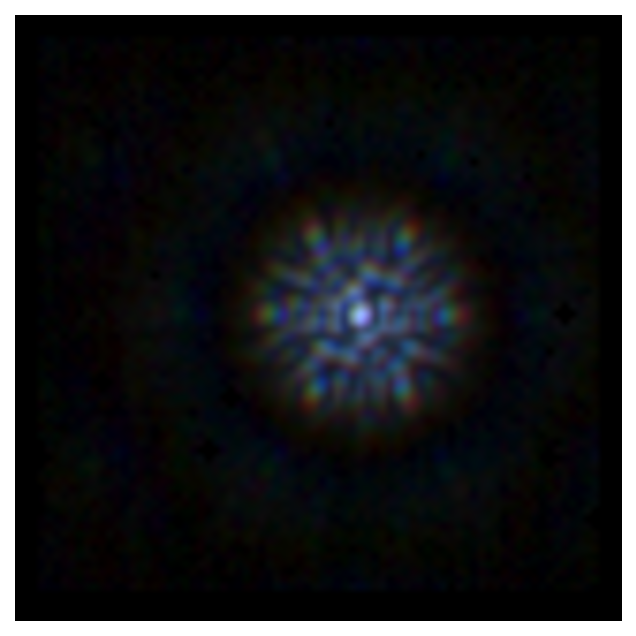

In [ ]:
badpix = cal_fits[0].badpix

r = fits_filt["F480M"][0]
g = fits_filt["F430M"][0]
b = fits_filt["F380M"][0]

r_max = np.nanmax(r)
g_max = np.nanmax(g)
b_max = np.nanmax(b)
maxx = np.nanmax(np.array([r_max, g_max, b_max]))

r = np.clip(np.where(badpix, 0.0, r), 0.0) / maxx
g = np.clip(np.where(badpix, 0.0, g), 0.0) / maxx
b = np.clip(np.where(badpix, 0.0, b), 0.0) / maxx

p = 0.5
r = r**p
g = g**p
b = b**p

img = np.stack([r, g, b], axis=-1)  # Shape: (H, W, 3)

plt.imshow(
    img, norm=mpl.colors.PowerNorm(2.0), origin="lower", interpolation="spline16"
)
plt.axis("off")
plt.show()

In [ ]:
fits_filt

{'F480M': [Array([[ 2.25439453,  1.12597656, -1.06137824, ...,  3.30407071,
           1.11445582,  0.78926283],
         [-0.6696226 ,  1.34501004,  0.4717311 , ...,  1.3377279 ,
          -1.08677042,  1.80497468],
         [ 1.62242544,  3.01028538,  0.69599313, ...,  0.77123427,
           0.92819625, -3.05062699],
         ...,
         [ 1.6647135 ,  0.72207034, -1.35677087, ...,  3.951823  ,
           4.01559544, -1.64278924],
         [ 0.30506727,  1.12448299,  2.02729225, ...,  3.20000935,
           1.96922743, -0.77321696],
         [ 1.28850818, -1.62185335, -1.73979807, ...,  1.30781245,
           0.65887129, -0.19720818]], dtype=float64),
  Array([[-0.58235675, -0.65409249,  0.55603969, ..., -0.77338326,
          -0.41465095, -3.97851562],
         [ 2.07122803,  0.92087203, -2.35359931, ..., -0.47021484,
           2.26269531, -2.46775866],
         [ 0.62845755,  0.8398062 ,  0.87981981, ...,  0.96147341,
          -0.86291176, -1.03798318],
         ...,
         [